# Ten-year dynamic maps and a finite-source light curve

Point lenses move continuously while map construction is temporally batched.
This example uses the same 25-day map cadence and daily source cadence over a
full ten years as the primary production tutorial. Only the first, middle,
and final $1024^2$ point-source maps are copied to CPU. All 147 maps are
streamed through finite-source photometry and released.

The two source bands differ only in Gaussian size, so the larger source
smooths more small-scale magnification structure. An explicit mock zero point
places the median blue-band flux at 20 mag. The plotted axis is therefore
brightness in magnitudes rather than an unlabeled relative offset.


In [1]:
import torch
from matplotlib import pyplot as plt
import microcaustics as mc
import microcaustics.plotting as mcp

plt.rcParams.update(mcp.publication_style())
capabilities = mc.RuntimeCapabilities.detect()
use_cuda = capabilities.cuda_available
runtime_config = mc.RuntimeConfig(
    profiling="detailed",  # opt in to synchronized component timings
    device="cuda" if use_cuda else "cpu",
    backend="triton" if use_cuda and capabilities.triton_importable else "auto",
    dtype=torch.float32,
    strict_backend=use_cuda and capabilities.triton_importable,
)
print(mcp.runtime_description())

import numpy as np


Python 3.11.15 | PyTorch 2.12.1+cu130 | Windows AMD64 | CUDA 13.0, NVIDIA GeForce RTX 5070 Ti, compute capability 12.0


In [2]:
stars = mc.PointMassField(
        x_uas=torch.tensor([-0.8, 0.4, 1.1]),
        y_uas=torch.tensor([0.5, -0.7, 0.2]),
        mass_solar=torch.tensor([0.004974, 0.003183, 0.002579]),
        velocity_x_uas_per_day=torch.tensor([2.0e-4, -1.0e-4, 1.5e-4]),
        velocity_y_uas_per_day=torch.tensor([-1.0e-4, 1.0e-4, 0.5e-4]),
)
geometry = mc.SourceGeometry(
    (65, 65),
    (1.0e11, 1.0e11),
    (4800.0, 7500.0),
    ("blue", "red"),
)
source = mc.GaussianSource(geometry, sigma_m=(4.0e11, 7.0e11))
distances = mc.LensingDistances(1.0e25, 2.0e25, 1.0e25)
lens_region = mc.PlaneRegion((6.0, 6.0))
# This tutorial intentionally follows a 2 uas map around a much smaller
# Gaussian source. PlaneGrid is the advanced override for that use case.
source_grid = mc.PlaneGrid((1024 if use_cuda else 256,) * 2, (2.0, 2.0))
map_times = torch.arange(0.0, 3650.0 + 12.5, 25.0)
flux_times = torch.arange(0.0, 3650.0 + 0.5, 1.0)
method = mc.production_ipm_config(
    rays=10_000_000 if use_cuda else 262_144,
)
schedule = mc.production_dynamic_config()
system = mc.MicrolensingSystem(
    macro=mc.MacroLens(convergence=0.25, shear=0.10), distances=distances,
    stars=stars, source=source, source_grid=source_grid, lens_region=lens_region,
    duration_days=3650.0, runtime=runtime_config,
)


In [3]:
selected_times = (0.0, 1825.0, 3650.0)
curve = system.multirate_light_curve(
    map_times,
    flux_times,
    method=method,
    schedule=schedule,
    keep_maps_at_days=selected_times,
)
print("Map epochs:", len(map_times), "daily light-curve samples:", len(flux_times))
print("Retained map times:", sorted(curve.maps))
print("Delivered runtime [s]:", curve.timing.delivered_seconds)


Map epochs: 147 daily light-curve samples: 3651
Retained map times: [0.0, 1825.0, 3650.0]
Delivered runtime [s]: 39.16482269996777


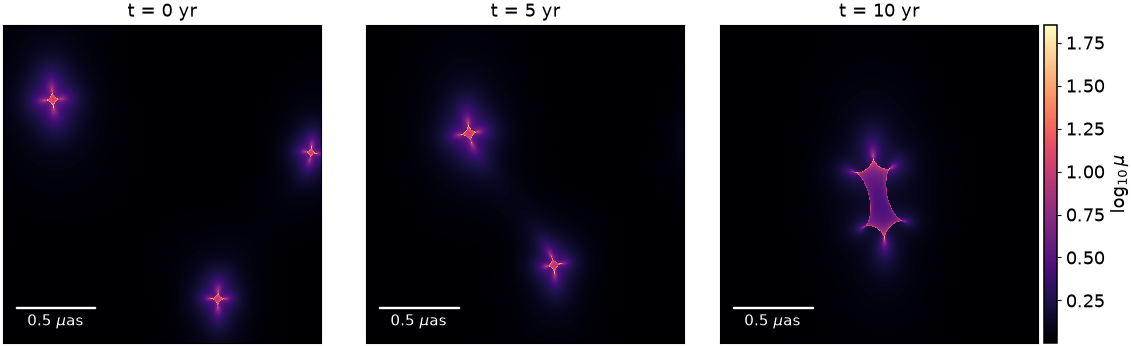

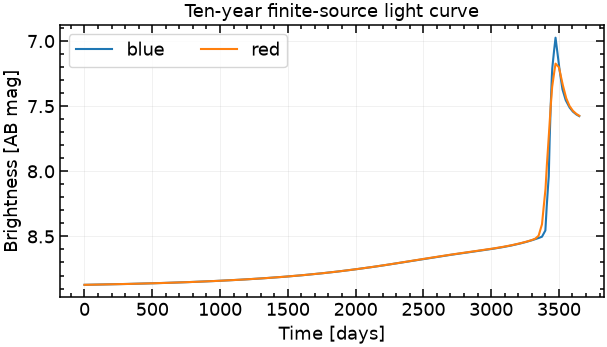

In [4]:
maps = [curve.maps[time_day] for time_day in selected_times]
log_values = [np.log10(np.clip(item.numpy(), 1.0e-12, None)) for item in maps]
vmin = min(float(values.min()) for values in log_values)
vmax = max(float(values.max()) for values in log_values)
figure, axes = plt.subplots(1, 3, figsize=(11.7, 3.7))
for ax, item in zip(axes, maps, strict=True):
    mcp.plot_magnification_map(
        item,
        ax=ax,
        log10=True,
        colorbar=False,
        vmin=vmin,
        vmax=vmax,
        scale_bar_uas=0.5,
        show_axes=False,
        title=f"t = {item.time_days / 365.0:.0f} yr",
    )
mcp.panel_colorbar(figure, axes[-1], axes[-1].images[0], label=r"$\log_{10}\mu$")
figure.tight_layout()

figure, ax = mcp.plot_light_curve(
    curve,
    magnitude=True,
    normalize=False,
    title="Ten-year finite-source light curve",
)
figure.tight_layout()
